# Sensitivity analysis / 敏感性分析

Change one input at a time around Baseline. Keep per-rack network power fixed. / 围绕基准每次只改变一个输入，机架网络功率保持固定。

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display, Image

# Support execution from the repository or notebooks directory.
# 支持从仓库根目录或 notebooks 目录执行。
ROOT = Path.cwd().resolve()
if not (ROOT / "src").is_dir():
    ROOT = ROOT.parent
if not (ROOT / "src").is_dir():
    raise RuntimeError("Start in the repository / 请从仓库目录启动")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))


In [2]:
from src.scenarios import load_scenarios
from src.sensitivity import run_sensitivity
baseline = next(inputs for row, inputs in load_scenarios(ROOT / "data/scenario_parameters.csv") if row["scenario"] == "Baseline")
sweeps = run_sensitivity(baseline, ROOT / "data/sensitivity_parameters.json")

## PUE sensitivity / PUE敏感性

The available IT budget decreases continuously with PUE. Whole-pod GPU capacity decreases in discrete steps. / 可用IT预算随PUE连续下降，完整Pod的GPU容量呈离散阶梯下降。

,pue,max_it_capacity_mw,max_pods,total_gpus,deployed_overhead_mw
0,1.1,454.545455,241,246784,45.26944
10,1.2,416.666667,221,226304,83.02528
20,1.3,384.615385,204,208896,114.95808
30,1.4,357.142857,190,194560,142.75840
40,1.5,333.333333,177,181248,166.23840
50,1.6,312.500000,166,169984,187.08864


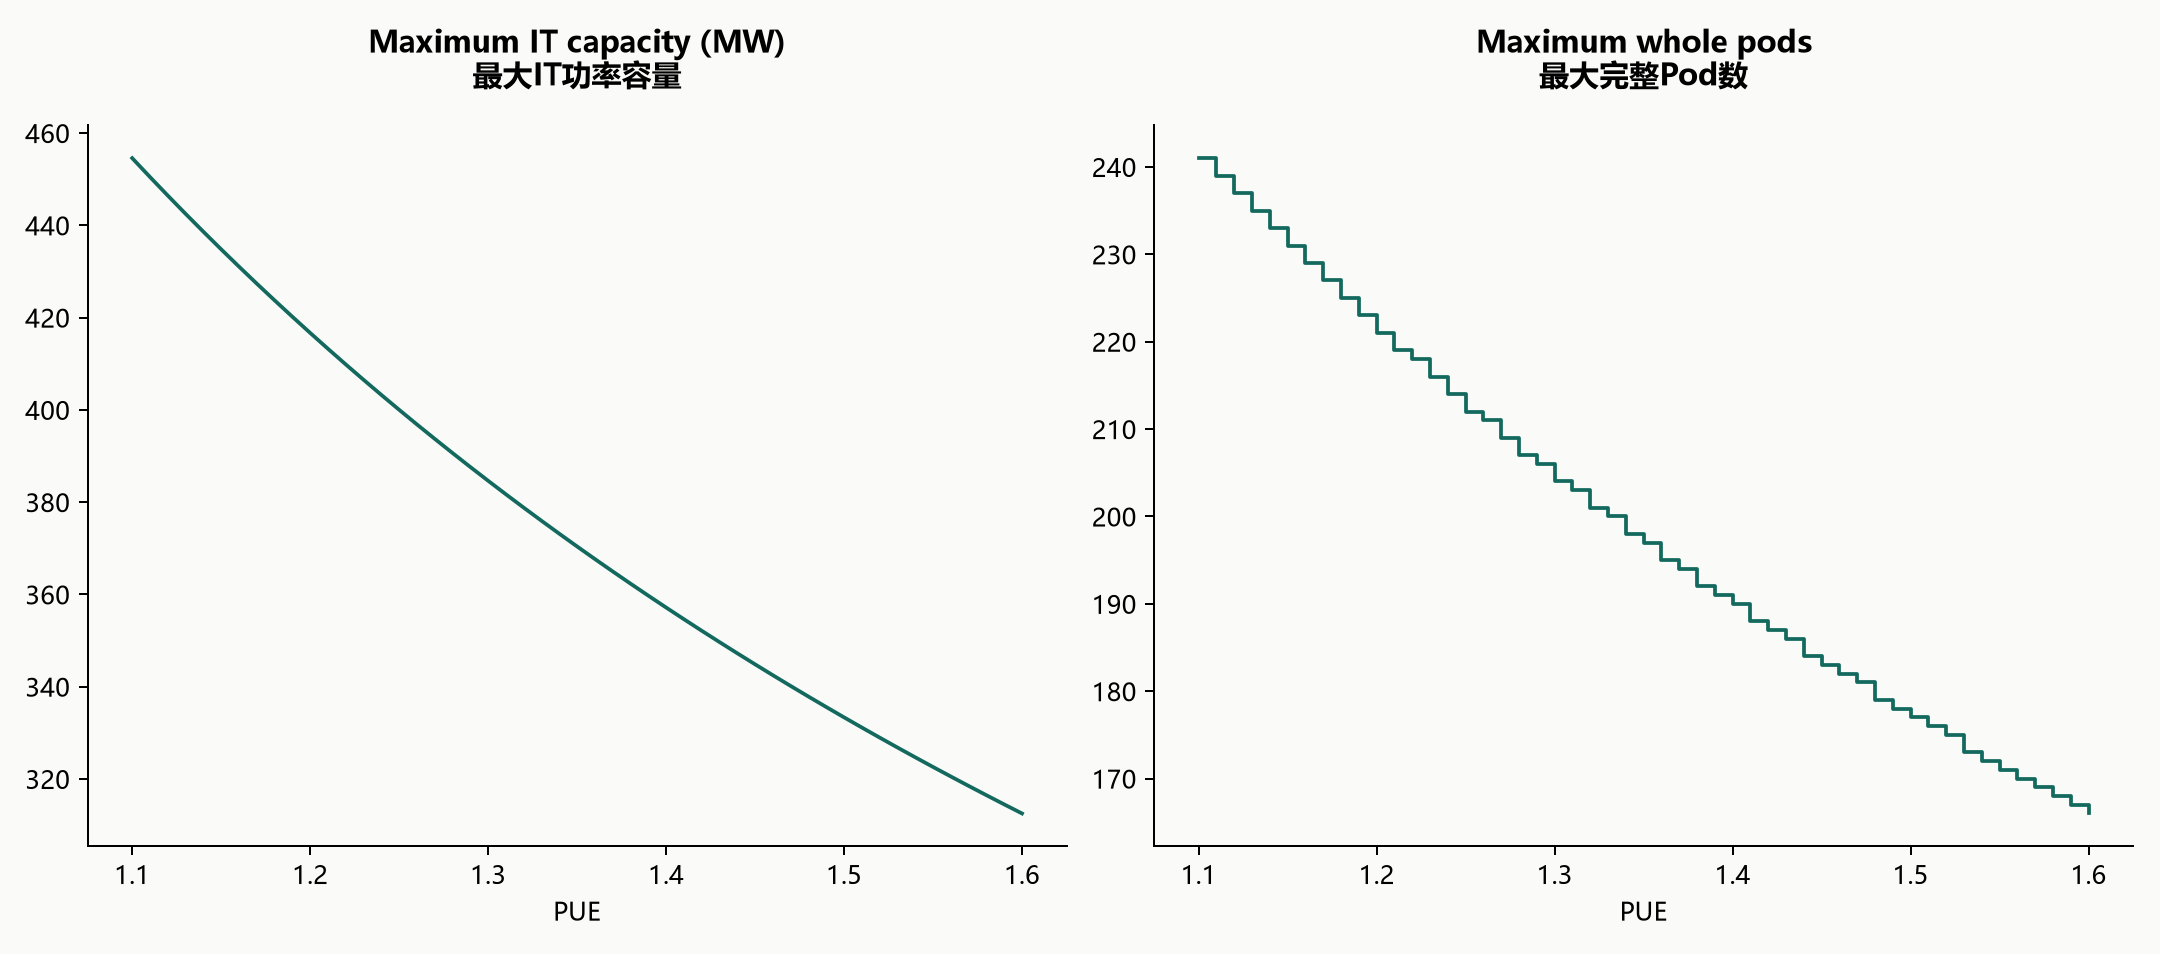

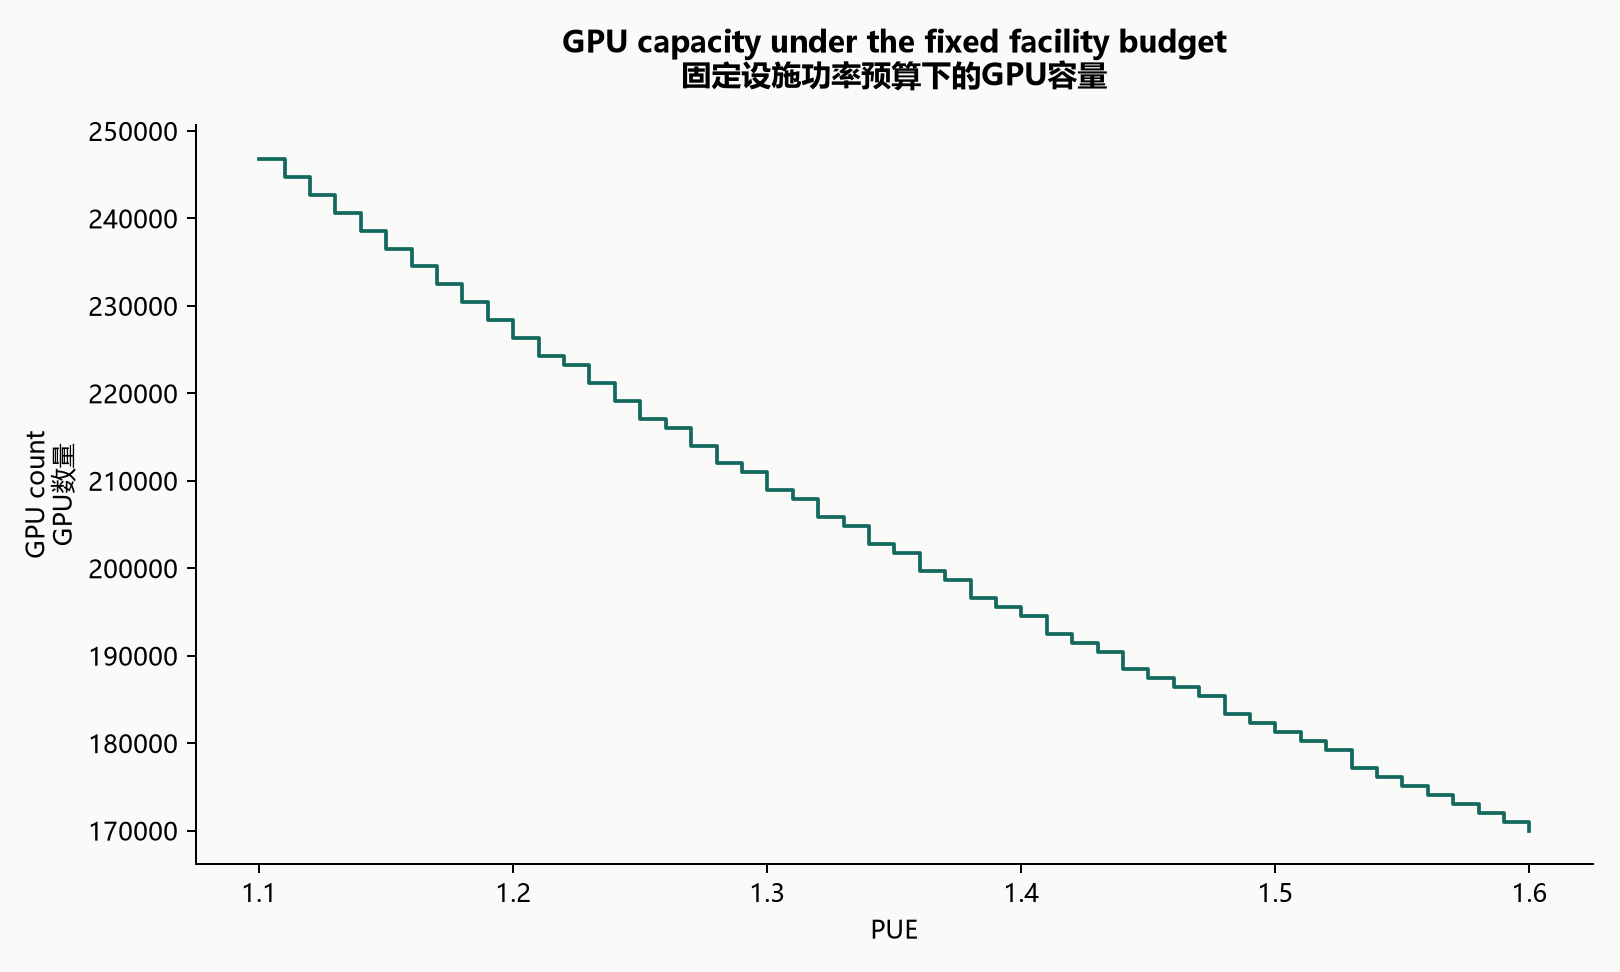

In [3]:
display(sweeps["pue"].iloc[::10][["pue", "max_it_capacity_mw", "max_pods", "total_gpus", "deployed_overhead_mw"]])
display(Image(filename=str(ROOT / "figures/pue_sensitivity.png")))
display(Image(filename=str(ROOT / "figures/gpu_capacity_vs_pue.png")))

## Rack density / 机架密度

With network kW fixed, more servers share the same external network power term. This assumption and integer packing determine the gain; physical fit is not evaluated. / 网络kW固定时，更多服务器分摊同一外部网络功率项。该假设与整数装填共同决定收益，未评估物理安装条件。

,servers_per_rack,rack_it_power_kw,max_pods,total_gpus,remaining_capacity_mw
0,1,15.8,824,210944,0.06272
1,2,30.1,432,221184,0.67712
2,3,44.4,293,225024,0.44672
3,4,58.7,221,226304,1.84832
4,5,73.0,178,227840,1.03040
5,6,87.3,149,228864,0.50432


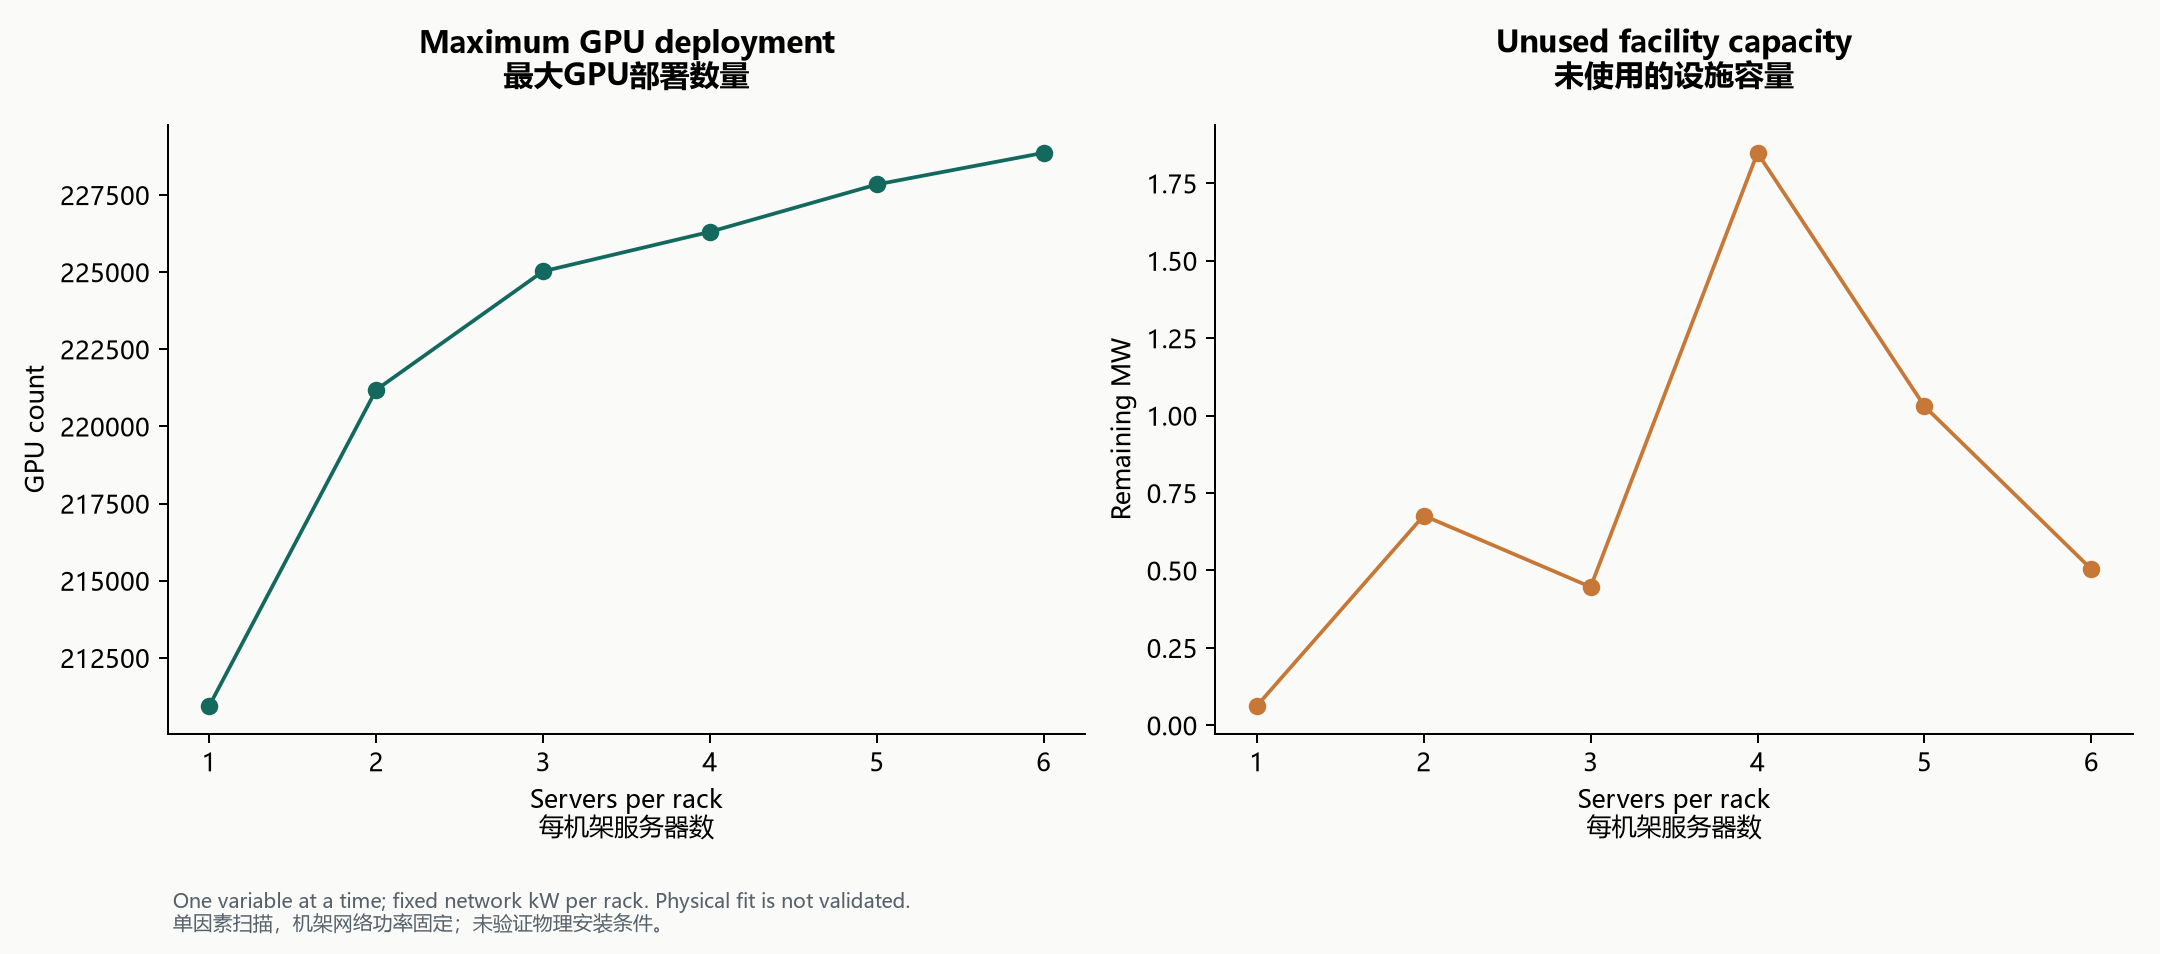

In [4]:
display(sweeps["rack_density"][["servers_per_rack", "rack_it_power_kw", "max_pods", "total_gpus", "remaining_capacity_mw"]])
display(Image(filename=str(ROOT / "figures/rack_density_sensitivity.png")))

## Pod size / Pod规模

Changing pod size changes deployment granularity. The unused power is not necessarily monotonic in pod size. / 改变Pod大小就是改变部署单元粒度，未使用功率不一定随Pod大小单调变化。

,racks_per_pod,pod_facility_power_mw,max_pods,total_racks,total_gpus,remaining_capacity_mw
0,8,0.56352,887,7096,227072,0.15776
1,16,1.12704,443,7088,226816,0.72128
2,24,1.69056,295,7080,226560,1.28480
3,32,2.25408,221,7072,226304,1.84832
4,40,2.81760,177,7080,226560,1.28480
5,48,3.38112,147,7056,225792,2.97536
6,56,3.94464,126,7056,225792,2.97536
7,64,4.50816,110,7040,225280,4.10240


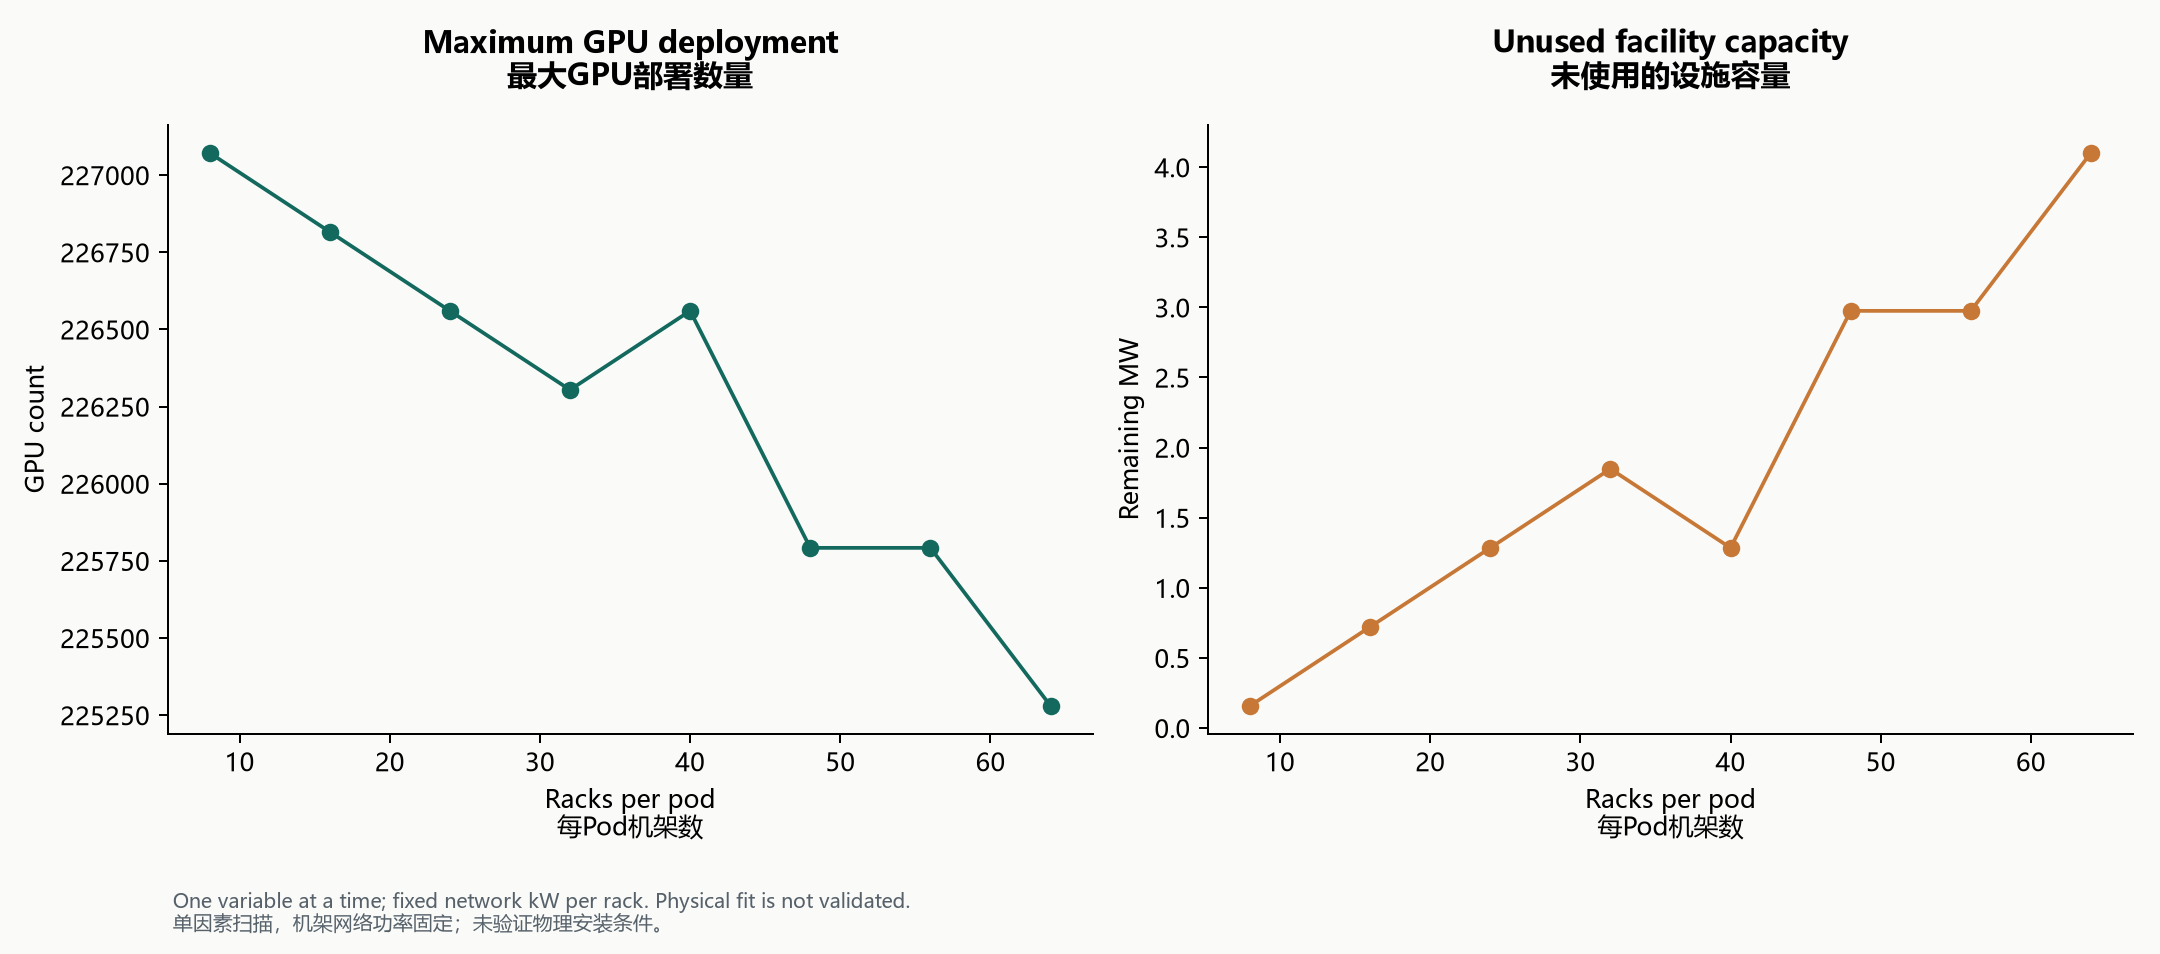

In [5]:
display(sweeps["pod_size"][["racks_per_pod", "pod_facility_power_mw", "max_pods", "total_racks", "total_gpus", "remaining_capacity_mw"]])
display(Image(filename=str(ROOT / "figures/pod_size_sensitivity.png")))

In [6]:
for frame in sweeps.values():
    assert (frame.remaining_capacity_mw >= 0).all()
    assert (frame.remaining_capacity_mw < frame.pod_facility_power_mw).all()
assert sweeps["pue"].total_gpus.is_monotonic_decreasing
print("Sensitivity invariants verified / 敏感性约束验证通过")

Sensitivity invariants verified / 敏感性约束验证通过


## Next steps / 后续方向

Explicit reserves, partial pods and physical rack constraints could make later planning more realistic. Real operational data and machine learning are outside this first phase. / 后续可加入明确预留、部分Pod与物理机架约束。真实运行数据及机器学习不属于当前第一阶段。